# Lecture 06 — Support Vector Machines & Kernel Methods

**Learning objectives**

- Formulate the maximum-margin classifier and derive the hard-margin primal problem.
- Relax it into the soft-margin SVM and recognise it as regularised hinge-loss minimisation.
- Derive the Lagrangian dual, the KKT conditions, and explain what makes a point a *support vector*.
- Implement a linear SVM from scratch with Pegasos-style stochastic subgradient descent and compare it with `sklearn.svm.SVC`.
- Understand the kernel trick (feature maps, Mercer's condition, RBF and polynomial kernels) and tune $C$ and $\gamma$.
- Apply support vector regression (SVR) and avoid the most common practical pitfall: unscaled features.

**Prerequisites**

- Linear models and gradient descent ([`02_linear_regression.ipynb`](02_linear_regression.ipynb), [`03_logistic_regression_and_classification.ipynb`](03_logistic_regression_and_classification.ipynb)).
- Regularisation and cross-validation ([`02_linear_regression.ipynb`](02_linear_regression.ipynb), [`04_model_evaluation_and_selection.ipynb`](04_model_evaluation_and_selection.ipynb)).
- Basic constrained optimisation (Lagrange multipliers).

**Contents**

1. Geometry of linear classifiers and the margin
2. Hard-margin SVM (primal)
3. Soft-margin SVM and the hinge loss
4. Lagrangian duality, KKT conditions and support vectors
5. From-scratch linear SVM (Pegasos) vs. scikit-learn
6. The kernel trick
7. Kernel SVMs on non-linear data: the effect of $C$ and $\gamma$
8. Support vector regression
9. Scaling pitfalls
10. Pitfalls & practical tips
11. Exercises
12. Summary and further reading

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings
from sklearn.datasets import make_blobs, make_moons, make_circles, load_breast_cancer
from sklearn.svm import SVC, LinearSVC, SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

%matplotlib inline
plt.rcParams["figure.figsize"] = (7, 4.5)
np.random.seed(42)
rng = np.random.default_rng(42)

## 1. Geometry of linear classifiers and the margin

Consider binary classification with labels $y_i \in \{-1, +1\}$ and a linear score $f(\mathbf{x}) = \mathbf{w}^\top\mathbf{x} + b$.
The decision boundary is the hyperplane $\mathcal{H} = \{\mathbf{x} : \mathbf{w}^\top \mathbf{x} + b = 0\}$ and we predict $\hat y = \operatorname{sign}(f(\mathbf{x}))$.

**Distance to the hyperplane.** For any point $\mathbf{x}_i$, its signed distance to $\mathcal{H}$ is
$$
\frac{\mathbf{w}^\top \mathbf{x}_i + b}{\lVert \mathbf{w} \rVert}.
$$
(Project $\mathbf{x}_i - \mathbf{x}_0$ onto the unit normal $\mathbf{w}/\lVert\mathbf{w}\rVert$, for any $\mathbf{x}_0 \in \mathcal{H}$.)
Multiplying by $y_i$ gives the **geometric margin** of a point, positive iff it is correctly classified:
$$
\gamma_i = \frac{y_i(\mathbf{w}^\top \mathbf{x}_i + b)}{\lVert \mathbf{w} \rVert}.
$$
The margin of the classifier on a data set is $\gamma = \min_i \gamma_i$.

**Why maximise the margin?** When data are linearly separable, infinitely many hyperplanes separate them
(the perceptron returns an arbitrary one). The maximum-margin hyperplane is

- *unique* (the problem below is strictly convex in $\mathbf{w}$),
- *robust*: small perturbations of the points of size $< \gamma$ cannot flip predictions,
- backed by *generalisation bounds*: for data in a ball of radius $R$, the VC-dimension of margin-$\gamma$ hyperplanes is bounded by $\min(d, R^2/\gamma^2) + 1$, independent of the ambient dimension $d$.

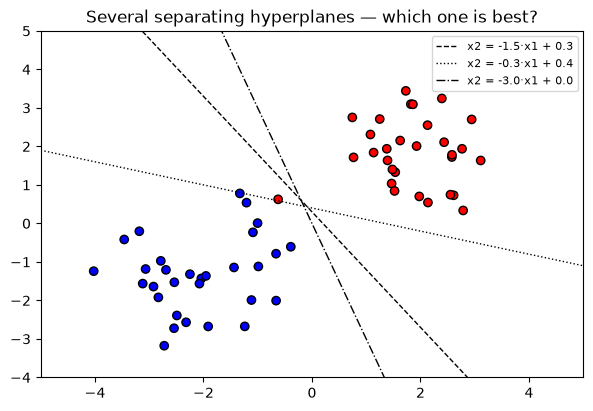

In [2]:
# Separable toy data: many separating lines exist, but they differ in margin
X_sep, y_sep = make_blobs(n_samples=60, centers=[[-2, -1], [2, 1.5]], cluster_std=0.9, random_state=3)
y_sep = np.where(y_sep == 0, -1, 1)

fig, ax = plt.subplots()
ax.scatter(X_sep[:, 0], X_sep[:, 1], c=y_sep, cmap="bwr", edgecolor="k")
xs = np.linspace(-5, 5, 10)
for slope, icpt, ls in [(-1.5, 0.3, "--"), (-0.3, 0.4, ":"), (-3.0, 0.0, "-.")]:
    ax.plot(xs, slope * xs + icpt, "k", ls=ls, lw=1, label=f"x2 = {slope}·x1 + {icpt}")
ax.set_xlim(-5, 5); ax.set_ylim(-4, 5); ax.legend(fontsize=8)
ax.set_title("Several separating hyperplanes — which one is best?")
plt.show()

## 2. Hard-margin SVM (primal)

The pair $(\mathbf{w}, b)$ is only defined up to a positive scale: $(c\mathbf{w}, cb)$ gives the same hyperplane.
We remove this freedom with the **canonical normalisation**
$$
\min_i \; y_i(\mathbf{w}^\top \mathbf{x}_i + b) = 1,
$$
so that the geometric margin becomes $\gamma = 1/\lVert\mathbf{w}\rVert$. Maximising $1/\lVert \mathbf{w} \rVert$ is equivalent to minimising $\tfrac12\lVert\mathbf{w}\rVert^2$, giving the **hard-margin primal**:
$$
\boxed{\;\min_{\mathbf{w}, b} \; \tfrac12 \lVert \mathbf{w} \rVert^2 \quad \text{s.t.} \quad y_i(\mathbf{w}^\top \mathbf{x}_i + b) \ge 1, \;\; i = 1,\dots,n.\;}
$$

This is a **quadratic program** (convex quadratic objective, linear constraints) in $d+1$ variables and $n$ constraints.
The two hyperplanes $\mathbf{w}^\top\mathbf{x} + b = \pm 1$ are the *margin boundaries*; the "street" between them has width $2/\lVert\mathbf{w}\rVert$.

It is feasible only if the data are linearly separable — a single outlier makes it infeasible. That motivates the soft margin.

## 3. Soft-margin SVM and the hinge loss

Introduce **slack variables** $\xi_i \ge 0$ that allow point $i$ to violate the margin by $\xi_i$:
$$
\min_{\mathbf{w}, b, \boldsymbol{\xi}} \; \tfrac12 \lVert \mathbf{w} \rVert^2 + C \sum_{i=1}^n \xi_i
\quad \text{s.t.} \quad y_i(\mathbf{w}^\top \mathbf{x}_i + b) \ge 1 - \xi_i, \;\; \xi_i \ge 0 .
$$

- $\xi_i = 0$: point on the correct side of its margin boundary.
- $0 < \xi_i \le 1$: inside the street but correctly classified.
- $\xi_i > 1$: misclassified. Hence $\sum_i \xi_i$ upper-bounds the number of training errors.

$C > 0$ trades off margin width against violations: **large $C$** $\Rightarrow$ few violations, narrow margin (low bias, high variance);
**small $C$** $\Rightarrow$ wide margin, many violations (more regularisation).

**Unconstrained form.** At the optimum each slack is as small as possible: $\xi_i = \max(0,\, 1 - y_i f(\mathbf{x}_i))$. Substituting,
$$
\min_{\mathbf{w}, b} \; \underbrace{\sum_{i=1}^n \max\big(0,\; 1 - y_i(\mathbf{w}^\top\mathbf{x}_i + b)\big)}_{\text{hinge loss}} \;+\; \frac{1}{2C}\lVert \mathbf{w} \rVert^2 .
$$
Dividing by $n$ and writing $\lambda = 1/(nC)$ gives the form used by Pegasos:
$$
J(\mathbf{w}, b) = \frac{\lambda}{2}\lVert\mathbf{w}\rVert^2 + \frac1n\sum_{i=1}^n \ell_{\text{hinge}}\big(y_i f(\mathbf{x}_i)\big), \qquad \ell_{\text{hinge}}(m) = \max(0, 1-m).
$$
So the SVM is simply **L2-regularised empirical risk minimisation with the hinge loss** — compare logistic regression, which uses $\log(1+e^{-m})$.
The hinge loss is a convex upper bound on the 0–1 loss, and it is *exactly zero* for $m \ge 1$: well-classified points contribute nothing, which is the origin of sparsity in support vectors.

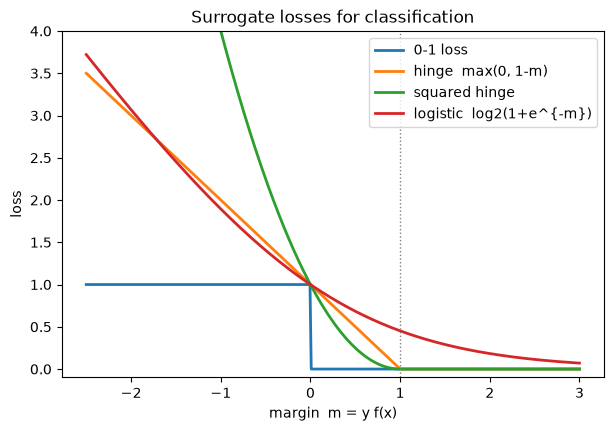

In [3]:
m = np.linspace(-2.5, 3, 400)
losses = {
    "0-1 loss": (m < 0).astype(float),
    "hinge  max(0, 1-m)": np.maximum(0, 1 - m),
    "squared hinge": np.maximum(0, 1 - m) ** 2,
    "logistic  log2(1+e^{-m})": np.log2(1 + np.exp(-m)),
}
fig, ax = plt.subplots()
for name, L in losses.items():
    ax.plot(m, L, label=name, lw=2)
ax.axvline(1, color="gray", ls=":", lw=1)
ax.set_ylim(-0.1, 4); ax.set_xlabel("margin  m = y f(x)"); ax.set_ylabel("loss")
ax.set_title("Surrogate losses for classification"); ax.legend()
plt.show()

## 4. Lagrangian duality, KKT conditions and support vectors

### 4.1 The Lagrangian

Introduce multipliers $\alpha_i \ge 0$ for the margin constraints and $\mu_i \ge 0$ for $\xi_i \ge 0$:
$$
\mathcal{L}(\mathbf{w}, b, \boldsymbol\xi, \boldsymbol\alpha, \boldsymbol\mu)
= \tfrac12\lVert\mathbf{w}\rVert^2 + C\sum_i \xi_i - \sum_i \alpha_i\big[y_i(\mathbf{w}^\top\mathbf{x}_i + b) - 1 + \xi_i\big] - \sum_i \mu_i \xi_i .
$$
The primal equals $\min_{\mathbf{w},b,\boldsymbol\xi}\max_{\boldsymbol\alpha,\boldsymbol\mu\ge0}\mathcal{L}$. Because the problem is convex and Slater's condition holds (strictly feasible points exist), **strong duality** holds and we can swap min and max.

### 4.2 Stationarity

Setting derivatives of $\mathcal L$ with respect to the primal variables to zero:
$$
\frac{\partial\mathcal L}{\partial \mathbf{w}} = 0 \;\Rightarrow\; \mathbf{w} = \sum_i \alpha_i y_i \mathbf{x}_i, \qquad
\frac{\partial\mathcal L}{\partial b} = 0 \;\Rightarrow\; \sum_i \alpha_i y_i = 0, \qquad
\frac{\partial\mathcal L}{\partial \xi_i} = 0 \;\Rightarrow\; \alpha_i = C - \mu_i .
$$
Since $\mu_i \ge 0$, the last condition gives the **box constraint** $0 \le \alpha_i \le C$.

### 4.3 The dual problem

Substituting back, the $\xi$ terms cancel ($C - \alpha_i - \mu_i = 0$), the $b$ term vanishes, and
$\tfrac12\lVert\mathbf{w}\rVert^2 - \sum_i\alpha_i y_i \mathbf{w}^\top\mathbf{x}_i = -\tfrac12\lVert\mathbf{w}\rVert^2$. Hence
$$
\boxed{\;\max_{\boldsymbol\alpha} \; \sum_{i=1}^n \alpha_i - \frac12 \sum_{i=1}^n\sum_{j=1}^n \alpha_i\alpha_j y_i y_j\, \mathbf{x}_i^\top\mathbf{x}_j
\quad\text{s.t.}\quad 0 \le \alpha_i \le C,\;\; \sum_i \alpha_i y_i = 0.\;}
$$
Two crucial observations:

1. The data enter **only through inner products** $\mathbf{x}_i^\top\mathbf{x}_j$ (the Gram matrix). This is what makes the kernel trick possible.
2. The dual has $n$ variables regardless of $d$ — attractive when $d \gg n$ or when the feature space is infinite-dimensional.

### 4.4 KKT conditions and support vectors

At the optimum, complementary slackness gives
$$
\alpha_i\big[y_i f(\mathbf{x}_i) - 1 + \xi_i\big] = 0, \qquad (C - \alpha_i)\,\xi_i = 0 .
$$
Therefore every training point falls into one of three categories:

| $\alpha_i$ | condition | location |
|---|---|---|
| $\alpha_i = 0$ | $y_i f(\mathbf{x}_i) \ge 1$ | outside the street — irrelevant to the solution |
| $0 < \alpha_i < C$ | $y_i f(\mathbf{x}_i) = 1$, $\xi_i = 0$ | exactly on the margin (*free* support vector) |
| $\alpha_i = C$ | $y_i f(\mathbf{x}_i) \le 1$ | inside the street or misclassified (*bounded* SV) |

Points with $\alpha_i > 0$ are the **support vectors**; $\mathbf{w} = \sum_{i \in SV} \alpha_i y_i\mathbf{x}_i$ depends only on them.
The bias follows from any free SV: $b = y_s - \mathbf{w}^\top\mathbf{x}_s$ (in practice averaged over all free SVs).
The prediction for a new point is
$$
f(\mathbf{x}) = \sum_{i\in SV}\alpha_i y_i\, \mathbf{x}_i^\top\mathbf{x} + b .
$$
A nice consequence: leave-one-out error $\le \#SV / n$, since removing a non-support vector does not change the solution.

**Solvers.** The dual QP is usually solved by *Sequential Minimal Optimisation* (SMO, Platt 1998), which repeatedly optimises two $\alpha$'s analytically (two because of the equality constraint). This is what `libsvm` (behind `SVC`) does; cost is roughly $O(n^2)$–$O(n^3)$. For linear SVMs on large data, primal methods (coordinate descent in `liblinear`/`LinearSVC`, or SGD) are faster.

### 4.5 Solving the dual numerically (small problem)

To make the dual concrete, we solve it with a generic constrained optimiser (`scipy.optimize.minimize`, SLSQP) on a tiny data set, then recover $\mathbf{w}$ and $b$ from the KKT conditions.
This does not scale, but it lets us check the theory directly.

In [4]:
from scipy.optimize import minimize

def svm_dual_qp(X, y, C=1.0):
    # Solve the soft-margin dual with SLSQP; returns alpha, w, b.
    n = len(y)
    K = X @ X.T                                   # Gram matrix of inner products
    Q = (y[:, None] * y[None, :]) * K             # Q_ij = y_i y_j x_i^T x_j
    obj  = lambda a: 0.5 * a @ Q @ a - a.sum()    # minimise the NEGATIVE dual
    grad = lambda a: Q @ a - 1.0
    cons = {"type": "eq", "fun": lambda a: a @ y, "jac": lambda a: y.astype(float)}
    res = minimize(obj, np.zeros(n), jac=grad, bounds=[(0, C)] * n,
                   constraints=[cons], method="SLSQP", options={"maxiter": 500})
    a = res.x
    w = (a * y) @ X                                # stationarity: w = sum a_i y_i x_i
    free = (a > 1e-5) & (a < C - 1e-5)             # free support vectors lie on the margin
    b = np.mean(y[free] - X[free] @ w)
    return a, w, b

C = 1.0
alpha, w_dual, b_dual = svm_dual_qp(X_sep, y_sep.astype(float), C=C)
svc_lin = SVC(kernel="linear", C=C).fit(X_sep, y_sep)

print("dual QP : w =", w_dual.round(4), " b =", round(b_dual, 4))
print("sklearn : w =", svc_lin.coef_.ravel().round(4), " b =", svc_lin.intercept_.round(4))
print("#SV (alpha > 1e-5):", (alpha > 1e-5).sum(), "  sklearn #SV:", svc_lin.n_support_.sum())
print("sum alpha_i y_i =", round(alpha @ y_sep, 6))

dual QP : w = [0.7324 0.4967]  b = -0.4129
sklearn : w = [0.7322 0.4966]  b = [-0.4129]
#SV (alpha > 1e-5): 4   sklearn #SV: 4
sum alpha_i y_i = -0.0


The generic QP and `libsvm`'s SMO agree, and only a handful of the 60 points have non-zero $\alpha_i$.
`SVC.dual_coef_` stores exactly the products $\alpha_i y_i$ for the support vectors — let us check the stationarity identity $\mathbf{w} = \sum_i \alpha_i y_i \mathbf{x}_i$ using sklearn's attributes.

In [5]:
w_from_sv = svc_lin.dual_coef_ @ svc_lin.support_vectors_
print("w from dual_coef_ @ support_vectors_:", w_from_sv.ravel().round(4))
print("0 <= |alpha_i| <= C ?", np.all(np.abs(svc_lin.dual_coef_) <= C + 1e-9))

w from dual_coef_ @ support_vectors_: [0.7322 0.4966]
0 <= |alpha_i| <= C ? True


## 5. From-scratch linear SVM: Pegasos (stochastic subgradient descent)

The hinge loss is convex but not differentiable at $m=1$, so we use a **subgradient**. For a single sample,
$$
\partial_{\mathbf{w}}\Big[\tfrac\lambda2\lVert\mathbf{w}\rVert^2 + \max(0, 1 - y_i(\mathbf{w}^\top\mathbf{x}_i + b))\Big] \ni
\begin{cases}
\lambda\mathbf{w} - y_i\mathbf{x}_i & \text{if } y_i f(\mathbf{x}_i) < 1,\\
\lambda\mathbf{w} & \text{otherwise},
\end{cases}
$$
and for the (unregularised) bias: $-y_i$ if $y_i f(\mathbf{x}_i)<1$, else $0$.

**Pegasos** (Shalev-Shwartz et al., 2007) uses the step size $\eta_t = 1/(\lambda t)$, which is optimal for $\lambda$-strongly-convex objectives and yields an $\tilde O(1/(\lambda T))$ convergence rate for the averaged iterate, independent of $n$. The update is
$$
\mathbf{w}_{t+1} = (1 - \eta_t\lambda)\,\mathbf{w}_t + \eta_t\, \mathbb{1}[y_i f(\mathbf{x}_i) < 1]\, y_i\mathbf{x}_i .
$$
The original algorithm has an optional projection onto the ball $\lVert\mathbf{w}\rVert \le 1/\sqrt\lambda$ (which contains the optimum). We use mini-batches, include an unregularised bias, and return the average of the last half of the iterates for stability.

To match `SVC(C=C)` which minimises $\tfrac12\lVert\mathbf w\rVert^2 + C\sum_i\xi_i$, we set $\lambda = 1/(nC)$.

In [6]:
class PegasosSVM:
    # Linear soft-margin SVM trained by mini-batch stochastic subgradient descent (Pegasos).
    def __init__(self, C=1.0, n_iter=20000, batch_size=8, seed=0):
        self.C, self.n_iter, self.batch_size, self.seed = C, n_iter, batch_size, seed

    def objective(self, X, y, w, b):
        # primal objective 0.5||w||^2 + C * sum hinge
        margins = y * (X @ w + b)
        return 0.5 * w @ w + self.C * np.maximum(0, 1 - margins).sum()

    def fit(self, X, y):
        rng = np.random.default_rng(self.seed)
        n, d = X.shape
        lam = 1.0 / (n * self.C)                      # lambda = 1/(nC) matches SVC's scaling
        w, b = np.zeros(d), 0.0
        w_avg, b_avg, n_avg = np.zeros(d), 0.0, 0
        self.history_ = []
        for t in range(1, self.n_iter + 1):
            idx = rng.integers(0, n, self.batch_size)
            Xb, yb = X[idx], y[idx]
            eta = 1.0 / (lam * t)                     # Pegasos step size
            viol = yb * (Xb @ w + b) < 1              # samples with non-zero hinge subgradient
            grad_w = lam * w - (yb[viol, None] * Xb[viol]).sum(0) / self.batch_size
            grad_b = -yb[viol].sum() / self.batch_size
            w = w - eta * grad_w
            # bias: use a smaller, non-exploding step (bias is not regularised)
            b = b - min(eta, 1.0) * grad_b * 0.1
            # optional projection onto ||w|| <= 1/sqrt(lambda)
            norm = np.linalg.norm(w)
            if norm > 1 / np.sqrt(lam):
                w *= (1 / np.sqrt(lam)) / norm
            if t > self.n_iter // 2:                  # average the second half of the iterates
                w_avg += w; b_avg += b; n_avg += 1
            if t % 200 == 0:
                self.history_.append(self.objective(X, y, w, b))
        self.w_, self.b_ = w_avg / n_avg, b_avg / n_avg
        return self

    def decision_function(self, X):
        return X @ self.w_ + self.b_

    def predict(self, X):
        return np.where(self.decision_function(X) >= 0, 1, -1)

We test on a *non-separable* 2-D problem (overlapping blobs), standardise features, and compare with `SVC(kernel="linear")` on (i) the parameters, (ii) the primal objective and (iii) accuracy.

Pegasos : w = [1.74 1.43], b = 0.148, obj = 73.323, acc = 0.913
SVC     : w = [1.741 1.44 ], b = 0.130, obj = 73.307, acc = 0.917


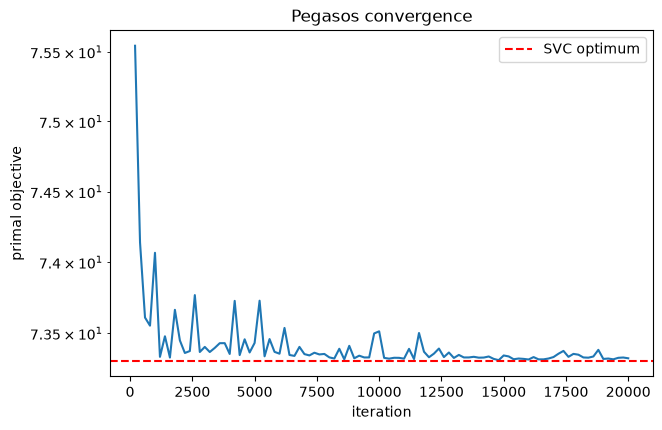

In [7]:
X2, y2 = make_blobs(n_samples=300, centers=[[-1.2, -1], [1.2, 1]], cluster_std=1.1, random_state=0)
y2 = np.where(y2 == 0, -1, 1)
X2 = StandardScaler().fit_transform(X2)

C = 1.0
peg = PegasosSVM(C=C, n_iter=20000, batch_size=16).fit(X2, y2)
svc = SVC(kernel="linear", C=C).fit(X2, y2)

w_sk, b_sk = svc.coef_.ravel(), svc.intercept_[0]
print(f"Pegasos : w = {peg.w_.round(3)}, b = {peg.b_:.3f}, obj = {peg.objective(X2, y2, peg.w_, peg.b_):.3f}, "
      f"acc = {(peg.predict(X2) == y2).mean():.3f}")
print(f"SVC     : w = {w_sk.round(3)}, b = {b_sk:.3f}, obj = {peg.objective(X2, y2, w_sk, b_sk):.3f}, "
      f"acc = {svc.score(X2, y2):.3f}")

plt.plot(np.arange(1, len(peg.history_) + 1) * 200, peg.history_)
plt.axhline(peg.objective(X2, y2, w_sk, b_sk), color="r", ls="--", label="SVC optimum")
plt.yscale("log"); plt.xlabel("iteration"); plt.ylabel("primal objective")
plt.title("Pegasos convergence"); plt.legend(); plt.show()

The objectives agree to within a small tolerance; SGD reaches the neighbourhood of the optimum quickly but approaches it slowly (sublinear rate), which is why exact solvers are preferred on small data.

### 5.1 Visualising margins and support vectors

We draw $f(\mathbf{x}) = 0$ (boundary) and $f(\mathbf{x}) = \pm 1$ (margins), and circle the support vectors returned by `SVC`.

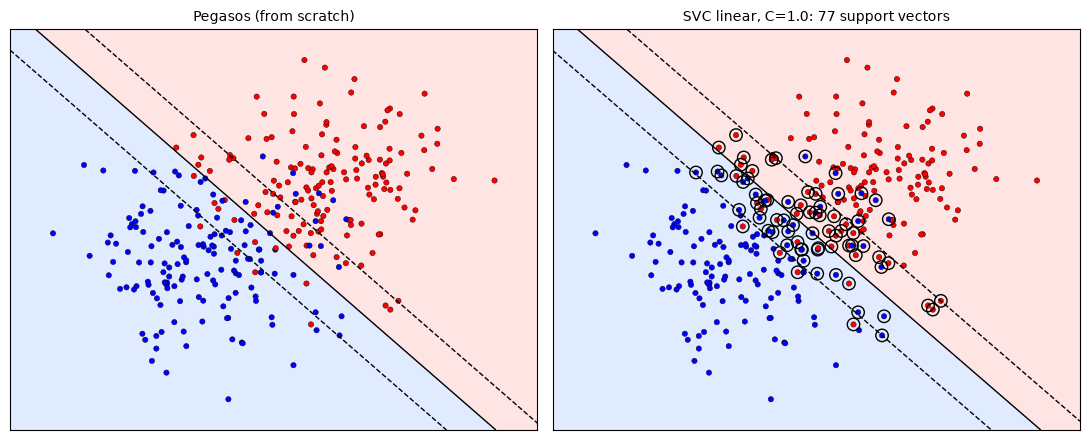

In [8]:
def plot_svm(ax, model, X, y, title, sv=None, h=300):
    x0 = np.linspace(X[:, 0].min() - .5, X[:, 0].max() + .5, h)
    x1 = np.linspace(X[:, 1].min() - .5, X[:, 1].max() + .5, h)
    XX, YY = np.meshgrid(x0, x1)
    Z = model.decision_function(np.c_[XX.ravel(), YY.ravel()]).reshape(XX.shape)
    ax.contourf(XX, YY, Z, levels=[-1e9, 0, 1e9], colors=["#aac8ff", "#ffb3b3"], alpha=0.35)
    ax.contour(XX, YY, Z, levels=[-1, 0, 1], colors="k", linestyles=["--", "-", "--"], linewidths=1)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", s=15, edgecolor="k", linewidth=0.3)
    if sv is not None:
        ax.scatter(sv[:, 0], sv[:, 1], s=80, facecolors="none", edgecolors="k", linewidths=1)
    ax.set_title(title, fontsize=10); ax.set_xticks([]); ax.set_yticks([])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
plot_svm(axes[0], peg, X2, y2, "Pegasos (from scratch)")
plot_svm(axes[1], svc, X2, y2, f"SVC linear, C={C}: {svc.n_support_.sum()} support vectors",
         sv=svc.support_vectors_)
plt.tight_layout(); plt.show()

### 5.2 Effect of $C$ on the margin

Small $C$ = strong regularisation = wide street with many support vectors; large $C$ = narrow street with few support vectors.

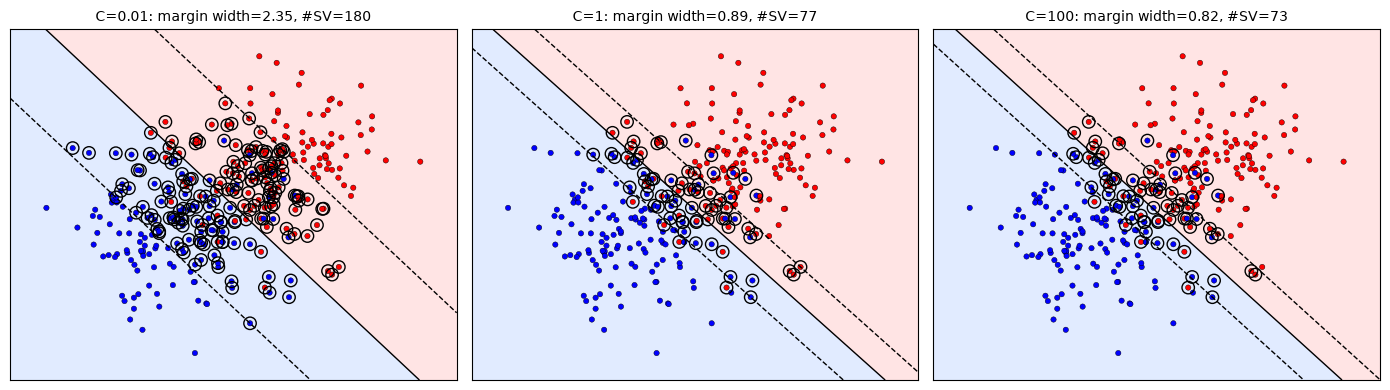

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, C in zip(axes, [0.01, 1, 100]):
    m = SVC(kernel="linear", C=C).fit(X2, y2)
    width = 2 / np.linalg.norm(m.coef_)
    plot_svm(ax, m, X2, y2, f"C={C}: margin width={width:.2f}, #SV={m.n_support_.sum()}",
             sv=m.support_vectors_)
plt.tight_layout(); plt.show()

## 6. The kernel trick

### 6.1 Feature maps

A linear classifier in a transformed space $\phi(\mathbf{x}) \in \mathcal{F}$ is non-linear in the input space. Example in 2-D with the degree-2 map
$$
\phi(x_1, x_2) = \big(x_1^2,\; \sqrt2\,x_1x_2,\; x_2^2\big)
\quad\Rightarrow\quad
\phi(\mathbf{x})^\top\phi(\mathbf{z}) = x_1^2z_1^2 + 2x_1x_2z_1z_2 + x_2^2z_2^2 = (\mathbf{x}^\top\mathbf{z})^2 .
$$
The inner product in feature space can be computed **without ever forming $\phi$**. Since the dual and the prediction rule use only inner products, we replace $\mathbf{x}_i^\top\mathbf{x}_j$ by a **kernel** $k(\mathbf{x}_i, \mathbf{x}_j) = \langle\phi(\mathbf{x}_i),\phi(\mathbf{x}_j)\rangle$:
$$
\max_{\boldsymbol\alpha}\sum_i\alpha_i - \tfrac12\sum_{i,j}\alpha_i\alpha_jy_iy_j\,k(\mathbf{x}_i,\mathbf{x}_j),
\qquad f(\mathbf{x}) = \sum_{i\in SV}\alpha_iy_i\,k(\mathbf{x}_i,\mathbf{x}) + b .
$$

### 6.2 Mercer's condition

Which functions $k$ are valid, i.e. correspond to *some* feature map? **Mercer / Moore–Aronszajn:** $k$ is a valid kernel iff it is symmetric and **positive semi-definite**: for every finite set $\{\mathbf{x}_1,\dots,\mathbf{x}_n\}$ the Gram matrix $K_{ij}=k(\mathbf{x}_i,\mathbf{x}_j)$ satisfies $\mathbf{c}^\top K\mathbf{c}\ge0$ for all $\mathbf{c}$. Then there exists a *reproducing kernel Hilbert space* (RKHS) $\mathcal{H}_k$ with $k(\mathbf{x},\mathbf{z}) = \langle\phi(\mathbf{x}),\phi(\mathbf{z})\rangle_{\mathcal H_k}$. PSD-ness also keeps the dual QP convex.

Closure rules: if $k_1,k_2$ are kernels then so are $k_1+k_2$, $c\,k_1$ ($c>0$), $k_1k_2$, $f(\mathbf{x})k_1(\mathbf{x},\mathbf{z})f(\mathbf{z})$, and $\exp(k_1)$.

### 6.3 Common kernels

| kernel | $k(\mathbf{x},\mathbf{z})$ | feature space |
|---|---|---|
| linear | $\mathbf{x}^\top\mathbf{z}$ | $\mathbb{R}^d$ |
| polynomial | $(\gamma\,\mathbf{x}^\top\mathbf{z} + r)^p$ | all monomials up to degree $p$: $\binom{d+p}{p}$ dims |
| RBF (Gaussian) | $\exp(-\gamma\lVert\mathbf{x}-\mathbf{z}\rVert^2)$ | infinite-dimensional |
| sigmoid | $\tanh(\gamma\,\mathbf{x}^\top\mathbf{z}+r)$ | *not* PSD in general |

For the RBF kernel, expanding $\exp(2\gamma\mathbf{x}^\top\mathbf{z})$ in a Taylor series shows it is an infinite weighted sum of polynomial kernels. $\gamma = 1/(2\sigma^2)$ sets the length scale: **large $\gamma$** $\Rightarrow$ each training point influences only a tiny neighbourhood (wiggly boundaries, overfitting); **small $\gamma$** $\Rightarrow$ smooth, nearly linear boundaries.

**Representer theorem.** For any loss and a regulariser that is increasing in $\lVert f\rVert_{\mathcal H_k}$, the minimiser has the form $f(\cdot) = \sum_i\beta_i k(\mathbf{x}_i,\cdot)$ — this is why the SVM solution is a kernel expansion over training points.

In [10]:
# Verify the degree-2 feature map identity and the PSD property numerically
def phi2(X):
    return np.c_[X[:, 0] ** 2, np.sqrt(2) * X[:, 0] * X[:, 1], X[:, 1] ** 2]

Xr = rng.normal(size=(50, 2))
K_explicit = phi2(Xr) @ phi2(Xr).T
K_kernel = (Xr @ Xr.T) ** 2
print("max |phi(x)^T phi(z) - (x^T z)^2| =", np.abs(K_explicit - K_kernel).max())

def rbf_kernel_np(A, B, gamma=1.0):
    # ||a-b||^2 = ||a||^2 + ||b||^2 - 2 a^T b, computed without loops
    sq = (A ** 2).sum(1)[:, None] + (B ** 2).sum(1)[None, :] - 2 * A @ B.T
    return np.exp(-gamma * np.maximum(sq, 0))

for name, K in [("RBF", rbf_kernel_np(Xr, Xr, 0.5)), ("poly deg 3", (Xr @ Xr.T + 1) ** 3),
                ("sigmoid", np.tanh(2.0 * Xr @ Xr.T - 1.0))]:
    print(f"{name:10s}: smallest eigenvalue of Gram matrix = {np.linalg.eigvalsh(K).min(): .3e}")

max |phi(x)^T phi(z) - (x^T z)^2| = 7.105427357601002e-15
RBF       : smallest eigenvalue of Gram matrix =  1.609e-11
poly deg 3: smallest eigenvalue of Gram matrix = -8.563e-14
sigmoid   : smallest eigenvalue of Gram matrix = -2.365e+01


The RBF and polynomial Gram matrices are PSD (smallest eigenvalue $\ge 0$ up to round-off), whereas the sigmoid "kernel" can have clearly negative eigenvalues.

### 6.4 A kernel SVM with a precomputed kernel

To confirm that `SVC` uses nothing but the Gram matrix, we pass our own RBF kernel with `kernel="precomputed"` and compare predictions with the built-in RBF.

In [11]:
Xm, ym = make_moons(n_samples=300, noise=0.2, random_state=0)
Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(Xm, ym, test_size=0.3, random_state=0)
g = 1.0
svc_pre = SVC(kernel="precomputed", C=1.0).fit(rbf_kernel_np(Xm_tr, Xm_tr, g), ym_tr)
svc_rbf = SVC(kernel="rbf", gamma=g, C=1.0).fit(Xm_tr, ym_tr)
pred_pre = svc_pre.predict(rbf_kernel_np(Xm_te, Xm_tr, g))   # rows: test, cols: training points
print("agreement precomputed vs built-in:", (pred_pre == svc_rbf.predict(Xm_te)).mean())
print("test accuracy:", svc_rbf.score(Xm_te, ym_te))

agreement precomputed vs built-in: 1.0
test accuracy: 1.0


## 7. Kernel SVMs on non-linear data: the effect of $C$ and $\gamma$

A linear SVM cannot separate concentric circles or interleaving moons. Polynomial and RBF kernels can.

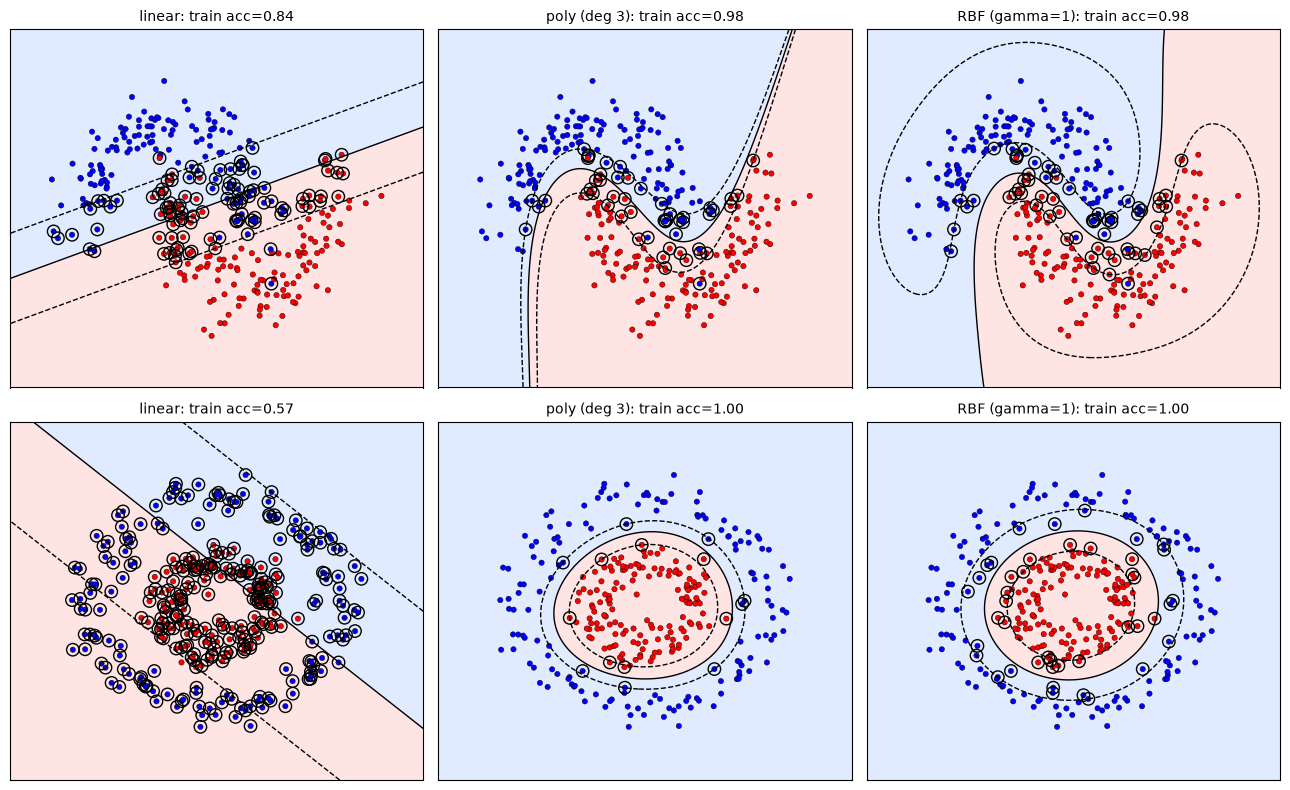

In [12]:
Xc, yc = make_circles(n_samples=300, noise=0.1, factor=0.4, random_state=0)
models = [("linear", SVC(kernel="linear", C=1)),
          ("poly (deg 3)", SVC(kernel="poly", degree=3, coef0=1, C=1)),
          ("RBF (gamma=1)", SVC(kernel="rbf", gamma=1, C=1))]
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for row, (X_, y_) in enumerate([(Xm, ym), (Xc, yc)]):
    for ax, (name, m) in zip(axes[row], models):
        m.fit(X_, y_)
        plot_svm(ax, m, X_, 2 * y_ - 1, f"{name}: train acc={m.score(X_, y_):.2f}", sv=m.support_vectors_)
plt.tight_layout(); plt.show()

### 7.1 A grid over $(C, \gamma)$

$C$ controls the penalty on margin violations, $\gamma$ the kernel width. Both push toward complexity when increased. The grid below shows the classic bias–variance picture: top-left (small $C$, small $\gamma$) underfits, bottom-right overfits.

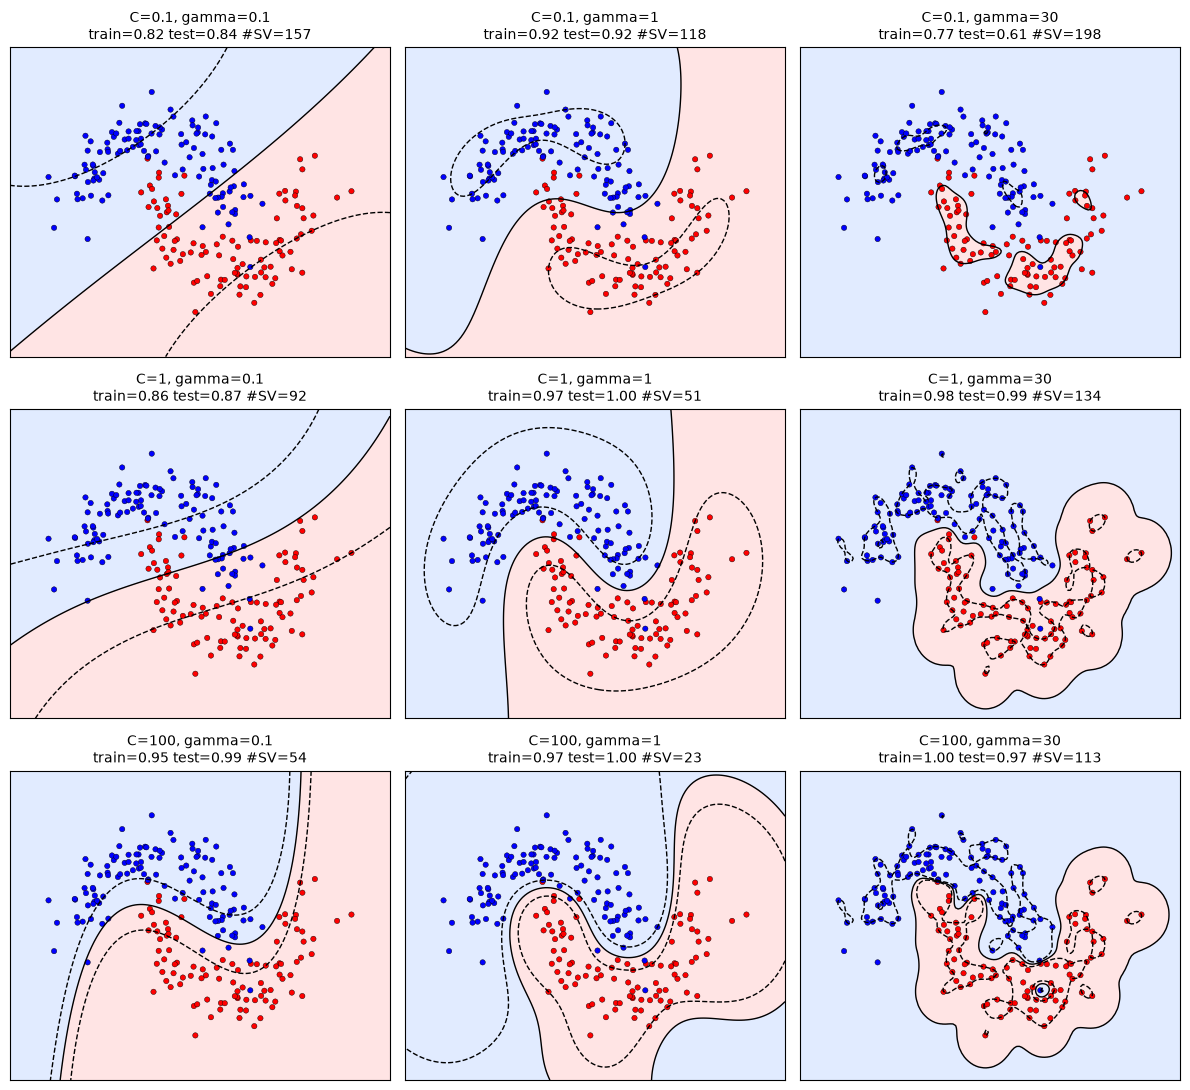

In [13]:
Cs, gammas = [0.1, 1, 100], [0.1, 1, 30]
fig, axes = plt.subplots(3, 3, figsize=(12, 11))
for i, C in enumerate(Cs):
    for j, gm in enumerate(gammas):
        m = SVC(kernel="rbf", C=C, gamma=gm).fit(Xm_tr, ym_tr)
        plot_svm(axes[i, j], m, Xm_tr, 2 * ym_tr - 1,
                 f"C={C}, gamma={gm}\ntrain={m.score(Xm_tr, ym_tr):.2f} test={m.score(Xm_te, ym_te):.2f} #SV={m.n_support_.sum()}",
                 h=150)
plt.tight_layout(); plt.show()

In practice, $(C,\gamma)$ are chosen by cross-validation on a **logarithmic grid**. The heatmap of mean CV accuracy typically shows a diagonal ridge: increasing $C$ can partly compensate for decreasing $\gamma$ and vice versa.

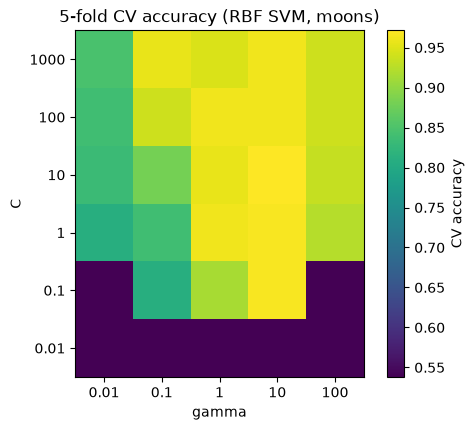

best params: {'C': np.float64(10.0), 'gamma': np.float64(10.0)}  test accuracy: 0.989


In [14]:
param_grid = {"C": np.logspace(-2, 3, 6), "gamma": np.logspace(-2, 2, 5)}
gs = GridSearchCV(SVC(kernel="rbf"), param_grid, cv=5, n_jobs=-1).fit(Xm_tr, ym_tr)
scores = gs.cv_results_["mean_test_score"].reshape(len(param_grid["C"]), len(param_grid["gamma"]))

fig, ax = plt.subplots(figsize=(6, 4.5))
im = ax.imshow(scores, cmap="viridis", origin="lower")
ax.set_xticks(range(5)); ax.set_xticklabels([f"{g:g}" for g in param_grid["gamma"]])
ax.set_yticks(range(6)); ax.set_yticklabels([f"{c:g}" for c in param_grid["C"]])
ax.set_xlabel("gamma"); ax.set_ylabel("C"); plt.colorbar(im, label="CV accuracy")
ax.set_title("5-fold CV accuracy (RBF SVM, moons)"); plt.show()
print("best params:", gs.best_params_, " test accuracy:", round(gs.score(Xm_te, ym_te), 3))

## 8. Support vector regression (SVR)

SVR replaces the hinge loss with the **$\varepsilon$-insensitive loss** $\ell_\varepsilon(r) = \max(0, |r| - \varepsilon)$, with $r = y - f(\mathbf{x})$: errors smaller than $\varepsilon$ are ignored (the "$\varepsilon$-tube"). The primal is
$$
\min_{\mathbf{w},b,\xi,\xi^*} \tfrac12\lVert\mathbf{w}\rVert^2 + C\sum_i(\xi_i + \xi_i^*)
\quad\text{s.t.}\quad
y_i - f(\mathbf{x}_i) \le \varepsilon + \xi_i,\;\; f(\mathbf{x}_i) - y_i \le \varepsilon + \xi_i^*,\;\; \xi_i,\xi_i^*\ge0 .
$$
Its dual has two multipliers per point, $f(\mathbf{x}) = \sum_i(\alpha_i - \alpha_i^*)k(\mathbf{x}_i,\mathbf{x}) + b$, and only points on or outside the tube are support vectors. Larger $\varepsilon$ means fewer SVs and a flatter fit.

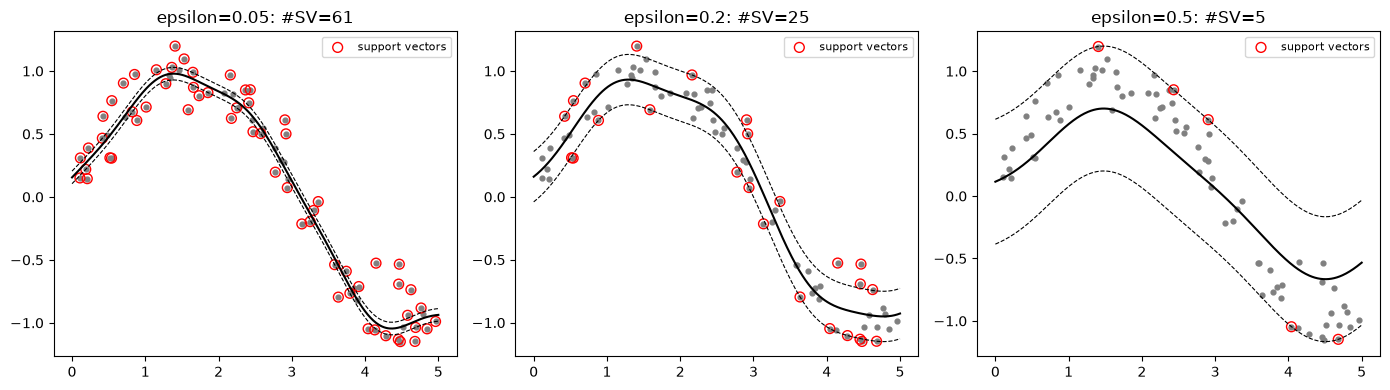

In [15]:
Xs = np.sort(rng.uniform(0, 5, 80))[:, None]
ys = np.sin(Xs).ravel() + rng.normal(0, 0.15, 80)
xg = np.linspace(0, 5, 400)[:, None]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, eps in zip(axes, [0.05, 0.2, 0.5]):
    svr = SVR(kernel="rbf", C=10, gamma=1.0, epsilon=eps).fit(Xs, ys)
    yg = svr.predict(xg)
    ax.scatter(Xs, ys, s=12, c="gray")
    ax.scatter(Xs[svr.support_], ys[svr.support_], s=50, facecolors="none", edgecolors="r", label="support vectors")
    ax.plot(xg, yg, "k"); ax.plot(xg, yg + eps, "k--", lw=0.8); ax.plot(xg, yg - eps, "k--", lw=0.8)
    ax.set_title(f"epsilon={eps}: #SV={len(svr.support_)}"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 9. Scaling pitfalls

SVMs are **not scale-invariant**. The RBF kernel depends on $\lVert\mathbf{x}-\mathbf{z}\rVert^2 = \sum_j (x_j - z_j)^2$: a feature measured in large units dominates the distance, and the others are effectively ignored. Likewise, the penalty $\lVert\mathbf{w}\rVert^2$ treats all coordinates equally only if they are on comparable scales.

The breast cancer data set has features ranging from $\sim10^{-3}$ to $\sim10^{3}$. We compare an RBF SVM with and without standardisation — with the scaler **inside a pipeline** so that it is fit only on training folds (avoiding leakage).

In [16]:
Xb, yb = load_breast_cancer(return_X_y=True)
print("feature std range: %.4f ... %.1f" % (Xb.std(0).min(), Xb.std(0).max()))
for name, model in [("RBF SVC, raw features", SVC(kernel="rbf")),
                    ("RBF SVC, StandardScaler pipeline", make_pipeline(StandardScaler(), SVC(kernel="rbf"))),
                    ("Linear SVC, raw features", LinearSVC(C=1, max_iter=5000)),
                    ("Linear SVC, StandardScaler pipeline", make_pipeline(StandardScaler(), LinearSVC(C=1, max_iter=5000)))]:
    s = cross_val_score(model, Xb, yb, cv=5)
    print(f"{name:38s}: CV accuracy = {s.mean():.3f} +/- {s.std():.3f}")

feature std range: 0.0026 ... 568.9
RBF SVC, raw features                 : CV accuracy = 0.912 +/- 0.035
RBF SVC, StandardScaler pipeline      : CV accuracy = 0.974 +/- 0.015
Linear SVC, raw features              : CV accuracy = 0.949 +/- 0.014
Linear SVC, StandardScaler pipeline   : CV accuracy = 0.967 +/- 0.017


Standardising gives a large jump in accuracy for the RBF SVM, and also helps the linear SVM's optimiser converge.
Note also that the default `gamma="scale"` in sklearn uses $\gamma = 1/(d\cdot\operatorname{Var}(X))$, which partially compensates for overall scale but not for *differences between features*.

## 10. Pitfalls & practical tips

- **Always scale features** (StandardScaler or MinMaxScaler) and put the scaler in a `Pipeline` so it is fit within each CV fold.
- **Tune $C$ and $\gamma$ jointly on a log grid** (e.g. $C\in\{10^{-2},\dots,10^3\}$, $\gamma\in\{10^{-3},\dots,10^1\}$). Tuning them one at a time misses the diagonal ridge.
- **Scalability:** kernel `SVC` training is between $O(n^2)$ and $O(n^3)$ and stores the kernel cache; beyond ~$10^4$–$10^5$ samples use `LinearSVC`, `SGDClassifier(loss="hinge")`, or kernel approximations (`Nystroem`, `RBFSampler` random Fourier features) followed by a linear model.
- **Probabilities:** SVM scores are not probabilities. `SVC(probability=True)` fits Platt scaling with an internal 5-fold CV — slow, and can disagree with `predict`. Prefer `CalibratedClassifierCV` if you need calibrated outputs.
- **Class imbalance:** use `class_weight="balanced"`, which rescales $C$ per class.
- **Multiclass:** `SVC` uses one-vs-one ($K(K-1)/2$ classifiers); `LinearSVC` uses one-vs-rest.
- **Many support vectors** (a large fraction of $n$) is a warning sign: either the classes overlap heavily or $C$/$\gamma$ are poorly chosen; prediction cost scales with #SV.
- **When to prefer SVMs:** small-to-medium tabular data, high-dimensional sparse data (text), or when a good domain-specific kernel exists (strings, graphs). For large tabular data, gradient-boosted trees (Lecture 07) usually win.

## 11. Exercises

**Exercise 1 (pen & paper — margin).** Show that the distance between the hyperplanes $\mathbf{w}^\top\mathbf{x}+b=1$ and $\mathbf{w}^\top\mathbf{x}+b=-1$ is $2/\lVert\mathbf{w}\rVert$. For the hard-margin SVM, show that $\lVert\mathbf{w}^*\rVert^2 = \sum_i\alpha_i^*$. (*Hint:* use $\mathbf{w}=\sum_i\alpha_iy_i\mathbf{x}_i$ and complementary slackness.)

**Exercise 2 (pen & paper — dual of the hinge-loss SVM without bias).** Derive the dual of $\min_\mathbf{w}\frac12\lVert\mathbf{w}\rVert^2 + C\sum_i\max(0,1-y_i\mathbf{w}^\top\mathbf{x}_i)$ (no $b$). Which constraint of the dual disappears? Explain why this makes coordinate ascent on single $\alpha_i$'s possible (this is the algorithm in `liblinear`).

**Exercise 3 (pen & paper — kernels).** (a) Show that $k(\mathbf{x},\mathbf{z}) = (\mathbf{x}^\top\mathbf{z}+1)^2$ in $\mathbb{R}^2$ corresponds to an explicit 6-dimensional feature map, and write it down. (b) Using the closure rules, prove that the RBF kernel is PSD. (*Hint:* $\lVert\mathbf{x}-\mathbf{z}\rVert^2 = \lVert\mathbf{x}\rVert^2+\lVert\mathbf{z}\rVert^2-2\mathbf{x}^\top\mathbf{z}$.)

**Exercise 4 (coding — dual coordinate ascent).** Implement the dual coordinate ascent algorithm for the bias-free linear SVM from Exercise 2: for each $i$, update $\alpha_i \leftarrow \operatorname{clip}_{[0,C]}\big(\alpha_i - (y_i\mathbf{w}^\top\mathbf{x}_i - 1)/\lVert\mathbf{x}_i\rVert^2\big)$ and maintain $\mathbf{w}=\sum_i\alpha_iy_i\mathbf{x}_i$ incrementally. Compare with `LinearSVC(loss="hinge", fit_intercept=False, dual=True)`.

**Exercise 5 (coding — kernel approximation).** Random Fourier features: sample $\boldsymbol\omega_k\sim\mathcal N(0, 2\gamma I)$, $b_k\sim U[0,2\pi]$ and set $z(\mathbf{x}) = \sqrt{2/D}\,[\cos(\boldsymbol\omega_k^\top\mathbf{x}+b_k)]_{k=1}^D$. Show empirically that $z(\mathbf{x})^\top z(\mathbf{z})\approx\exp(-\gamma\lVert\mathbf{x}-\mathbf{z}\rVert^2)$ and train a linear SVM on $z(\mathbf{x})$ for the moons data. How does accuracy vary with $D$?

**Exercise 6 (coding — SVR).** On `load_diabetes`, tune an RBF `SVR` (with scaling) over $C$, $\gamma$, $\varepsilon$ and compare its test $R^2$ with ridge regression.

In [17]:
# Exercise 4 — TODO: dual coordinate ascent for the bias-free linear SVM
def dual_cd_svm(X, y, C=1.0, n_epochs=20, seed=0):
    # Return w (shape d,) and alpha (shape n,)
    n, d = X.shape
    alpha = np.zeros(n)
    w = np.zeros(d)
    # TODO: loop over epochs, permute indices, apply the clipped coordinate update,
    #       and update w incrementally: w += (alpha_new - alpha_old) * y_i * x_i
    return None

# Example usage once implemented:
# w_cd, a_cd = dual_cd_svm(X2, y2, C=1.0)

In [18]:
# Exercise 5 — TODO: random Fourier features for the RBF kernel
def random_fourier_features(X, D=200, gamma=1.0, seed=0):
    # Return the (n, D) matrix z(X)
    # TODO: draw omega ~ N(0, 2*gamma*I) of shape (d, D) and b ~ U[0, 2*pi] of shape (D,)
    pass

# Check: compare random_fourier_features(Xr) @ random_fourier_features(Xr).T with rbf_kernel_np(Xr, Xr)

## 12. Summary

- The SVM finds the **maximum-margin** hyperplane; with canonical scaling this is $\min\frac12\lVert\mathbf{w}\rVert^2$ subject to $y_if(\mathbf{x}_i)\ge1$.
- The **soft-margin** SVM is equivalent to L2-regularised **hinge-loss** minimisation; $C$ is an inverse regularisation strength.
- The **dual** depends on the data only through inner products; KKT complementary slackness shows the solution is a sparse combination of **support vectors** ($\alpha_i>0$).
- Primal stochastic subgradient methods (**Pegasos**) scale to large data; dual methods (SMO) are exact and support kernels.
- The **kernel trick** replaces inner products with any PSD kernel (Mercer), giving non-linear classifiers in possibly infinite-dimensional feature spaces.
- For the RBF kernel, $C$ and $\gamma$ jointly control complexity and must be tuned together by cross-validation.
- **SVR** uses the $\varepsilon$-insensitive loss; **scaling** features is essential for all SVMs.

## Further reading

- Hastie, Tibshirani & Friedman, *The Elements of Statistical Learning* (ESL), Ch. 12.
- James et al., *An Introduction to Statistical Learning* (ISLR/ISLP), Ch. 9.
- Bishop, *Pattern Recognition and Machine Learning* (PRML), Ch. 6 (kernels) and Ch. 7 (sparse kernel machines).
- Murphy, *Probabilistic Machine Learning: An Introduction* (PML), Ch. 17.
- Géron, *Hands-On Machine Learning*, Ch. 5.
- Schölkopf & Smola, *Learning with Kernels*, MIT Press, 2002.
- Cortes & Vapnik, "Support-vector networks", *Machine Learning*, 1995.
- Boser, Guyon & Vapnik, "A training algorithm for optimal margin classifiers", COLT 1992.
- Platt, "Sequential Minimal Optimization", Microsoft Research TR, 1998.
- Shalev-Shwartz, Singer & Srebro, "Pegasos: Primal Estimated sub-GrAdient SOlver for SVM", ICML 2007.
- Rahimi & Recht, "Random Features for Large-Scale Kernel Machines", NeurIPS 2007.